# **Global Configuration & Imports**

In [ ]:
# --- INSTALL COMMANDS (Uncomment if running in Colab for the first time) ---
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm imbalanced-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests
import joblib
import shap
import warnings
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any, List
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Suppress warnings for cleaner output in presentation
warnings.filterwarnings('ignore')

@dataclass
class ProjectConfig:
    """Global configuration for the BizLens project."""
    RANDOM_STATE: int = 42
    TEST_SIZE: float = 0.2
    TARGET_COL: str = 'Churn'
    # Define features to ensure consistency across training and inference
    CAT_FEATURES: Tuple[str, ...] = (
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaperlessBilling', 'PaymentMethod'
    )
    NUM_FEATURES: Tuple[str, ...] = ('tenure', 'MonthlyCharges', 'TotalCharges')

config = ProjectConfig()

def display_settings():
    """Sets pandas display options for better visibility in notebooks."""
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    # pd.set_option('display.max_rows', 100) # Optional

display_settings()
print("✅ Environment Configured & Libraries Imported")

✅ Environment Configured & Libraries Imported


# **Module: Data Ingestion Engine**

In [ ]:
class DataIngestion:
    """
    Handles data loading from various sources (URL, local file) and
    initial validations.
    """

    def __init__(self):
        self.file_category = None

    def _is_url(self, path: str) -> bool:
        """Private helper to check if path is a URL."""
        return path.startswith(("http://", "https://", "ftp://"))

    def load_data(self, file_path: str) -> pd.DataFrame:
        """
        Loads data from a CSV file path or URL.

        Args:
            file_path (str): The path or URL to the dataset.

        Returns:
            pd.DataFrame: The loaded pandas DataFrame.
        """
        try:
            if self._is_url(file_path):
                print(f"🌐 Detected URL. Downloading from: {file_path}...")
                response = requests.get(file_path)
                response.raise_for_status()
                # Assuming the content is CSV for this project context
                df = pd.read_csv(io.StringIO(response.content.decode('utf-8')))
            else:
                print(f"📂 Loading local file: {file_path}...")
                df = pd.read_csv(file_path)

            # Basic cleaning: Convert TotalCharges to numeric (coercing errors)
            # This is a common specific issue with the Telco dataset
            if 'TotalCharges' in df.columns:
                df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

            print(f"✅ Data Loaded Successfully. Shape: {df.shape}")
            return df

        except Exception as e:
            print(f"❌ Error loading data: {e}")
            raise

# --- EXECUTION BLOCK ---
# Using the standard Telco Churn URL for demonstration
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

loader = DataIngestion()
df_raw = loader.load_data(DATA_URL)
df_raw.head(3)

🌐 Detected URL. Downloading from: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv...
✅ Data Loaded Successfully. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


# **Module: Data Validation (The Logic Verifier)**

In [ ]:
def verify_churn_logic(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generates a high-level summary table to verify data permutations
    and logic consistency, matching the structure in the BizLens notebook.
    """
    print("🔍 Generating Verification Table...")

    # Creating a simplified profile string for grouping
    # This helps in spotting segments quickly (e.g., "Male, Non-senior")
    temp_df = df.copy()
    temp_df['Profile'] = (
        temp_df['gender'] + ", " +
        temp_df['SeniorCitizen'].apply(lambda x: "Senior" if x == 1 else "Non-senior")
    )

    # Grouping to count occurrences and check target distribution
    verification = temp_df.groupby(['Profile', 'Contract']).agg(
        Count=('customerID', 'count'),
        Churn_Rate=('Churn', lambda x: (x == 'Yes').mean())
    ).reset_index()

    # Formatting columns to match your PDF's style
    verification['Prediction_Logic'] = verification['Churn_Rate'].apply(
        lambda x: "P: High Risk" if x > 0.4 else "P: Low Risk"
    )

    # Sorting by count to see most common profiles
    verification = verification.sort_values(by='Count', ascending=False).head(10)

    print(f"✅ Total Groups Analyzed: {len(verification)}")
    return verification

# --- EXECUTION BLOCK ---
verification_table = verify_churn_logic(df_raw)
display(verification_table)

🔍 Generating Verification Table...
✅ Total Groups Analyzed: 10


,Profile,Contract,Count,Churn_Rate,Prediction_Logic
6,"Male, Non-senior",Month-to-month,1542,0.384565,P: Low Risk
0,"Female, Non-senior",Month-to-month,1526,0.406946,P: High Risk
2,"Female, Non-senior",Two year,777,0.024453,P: Low Risk
8,"Male, Non-senior",Two year,773,0.029754,P: Low Risk
7,"Male, Non-senior",One year,666,0.117117,P: Low Risk
1,"Female, Non-senior",One year,617,0.095624,P: Low Risk
9,"Male, Senior",Month-to-month,408,0.539216,P: High Risk
3,"Female, Senior",Month-to-month,399,0.553885,P: High Risk
4,"Female, Senior",One year,101,0.158416,P: Low Risk
10,"Male, Senior",One year,89,0.146067,P: Low Risk


# **Module: Exploratory Data Analysis (EDA)**

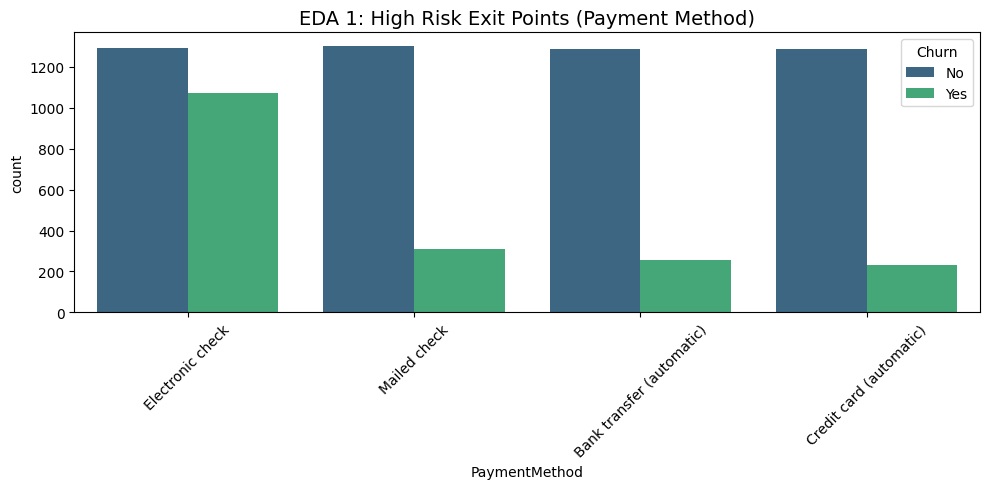

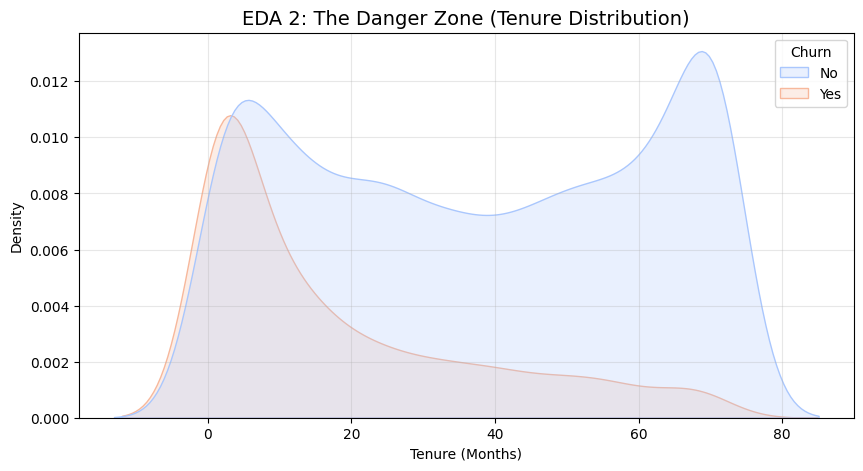

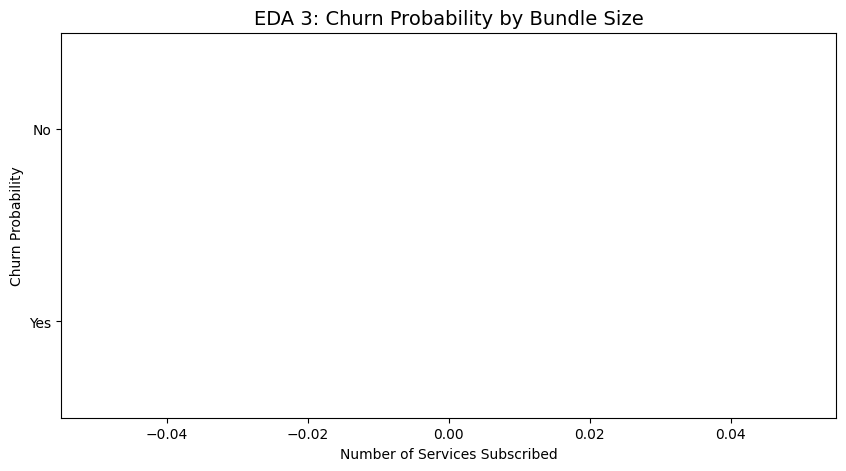

In [ ]:
class BizLensEDA:
    """
    Encapsulates specific EDA functions for BizLens Analytics.
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def plot_exit_points(self):
        """EDA 1: Identify high risk 'exit points' based on Payment Method."""
        plt.figure(figsize=(10, 5))
        ax = sns.countplot(data=self.df, x='PaymentMethod', hue='Churn', palette='viridis')
        plt.title("EDA 1: High Risk Exit Points (Payment Method)", fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_danger_zone(self):
        """EDA 2: Determine the 'Danger Zone' - Churn vs Tenure."""
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=self.df, x='tenure', hue='Churn', fill=True, palette='coolwarm')
        plt.title("EDA 2: The Danger Zone (Tenure Distribution)", fontsize=14)
        plt.xlabel("Tenure (Months)")
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_bundled_services(self):
        """EDA 3: Quantify how bundled services affect loyalty."""
        # Creating a proxy for 'Bundle Size'
        services = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

        # Count how many services contain 'Yes' (or specific internet service)
        # Note: Some cols have 'No internet service', we treat that as 0
        temp_df = self.df.copy()
        for col in services:
            temp_df[col] = temp_df[col].apply(lambda x: 1 if x not in ['No', 'No internet service', '0'] else 0)

        temp_df['Bundle_Size'] = temp_df[services].sum(axis=1)

        plt.figure(figsize=(10, 5))
        sns.barplot(data=temp_df, x='Bundle_Size', y='Churn',
                    estimator=lambda x: (x == 'Yes').mean(), ci=None, palette='magma')
        plt.title("EDA 3: Churn Probability by Bundle Size", fontsize=14)
        plt.ylabel("Churn Probability")
        plt.xlabel("Number of Services Subscribed")
        plt.show()

# --- EXECUTION BLOCK ---
eda = BizLensEDA(df_raw)
eda.plot_exit_points()
eda.plot_danger_zone()
eda.plot_bundled_services()

# **Module: Preprocessing & Feature Engineering**

In [ ]:
def build_preprocessor(config: ProjectConfig) -> ColumnTransformer:
    """
    Constructs the sklearn ColumnTransformer for the pipeline.
    Ensures numerical scaling and categorical encoding.
    """
    # 1. Numerical Pipeline: Impute missing -> Scale
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # 2. Categorical Pipeline: Impute missing -> OneHotEncode
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Combine them
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, config.NUM_FEATURES),
        ('cat', cat_pipeline, config.CAT_FEATURES)
    ], verbose_feature_names_out=False)

    return preprocessor

# --- EXECUTION BLOCK ---
# Clean target variable for training
X = df_raw.drop(columns=[config.TARGET_COL, 'customerID'])
y = df_raw[config.TARGET_COL].map({'Yes': 1, 'No': 0}) # Encode target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
)

print("✅ Data Split & Preprocessor Constructed")

✅ Data Split & Preprocessor Constructed


# **Module: Model Training (XGBoost + SMOTE)**

🚀 Starting Model Training (XGBoost + SMOTE)...
✅ Model Trained Successfully.

--- 📊 Model Performance Evaluation ---
ROC AUC Score: 0.8350

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



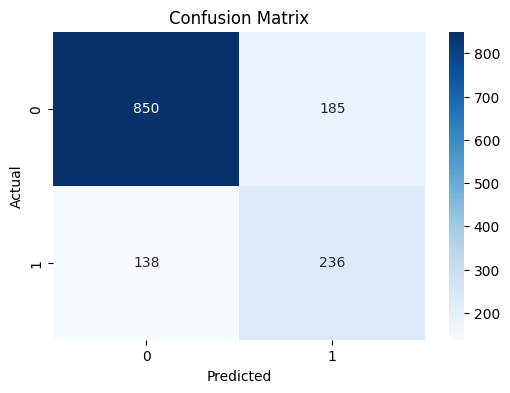

In [ ]:
class ModelTrainer:
    """
    Manages model training, evaluation, and persistence.
    """
    def __init__(self, preprocessor, random_state=42):
        self.preprocessor = preprocessor
        self.random_state = random_state
        self.pipeline = None

    def train_xgboost(self, X_train, y_train):
        """
        Trains an XGBoost classifier within a SMOTE pipeline.
        """
        print("🚀 Starting Model Training (XGBoost + SMOTE)...")

        # Define the full pipeline: Preprocess -> SMOTE -> Model
        self.pipeline = ImbPipeline([
            ('preprocessor', self.preprocessor),
            ('smote', SMOTE(random_state=self.random_state)),
            ('classifier', XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=self.random_state,
                n_estimators=200,      # Hyperparam to be tuned
                learning_rate=0.05,
                max_depth=5
            ))
        ])

        self.pipeline.fit(X_train, y_train)
        print("✅ Model Trained Successfully.")
        return self.pipeline

    def evaluate(self, X_test, y_test):
        """
        Prints classification report and ROC-AUC.
        """
        if not self.pipeline:
            raise ValueError("Model not trained yet!")

        y_pred = self.pipeline.predict(X_test)
        y_prob = self.pipeline.predict_proba(X_test)[:, 1]

        print("\n--- 📊 Model Performance Evaluation ---")
        print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        # Confusion Matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

# --- EXECUTION BLOCK ---
preprocessor = build_preprocessor(config)
trainer = ModelTrainer(preprocessor, config.RANDOM_STATE)
pipeline = trainer.train_xgboost(X_train, y_train)
trainer.evaluate(X_test, y_test)

# **Module: Interpretability (SHAP Values)**

🧠 Calculating SHAP Values for Interpretability...


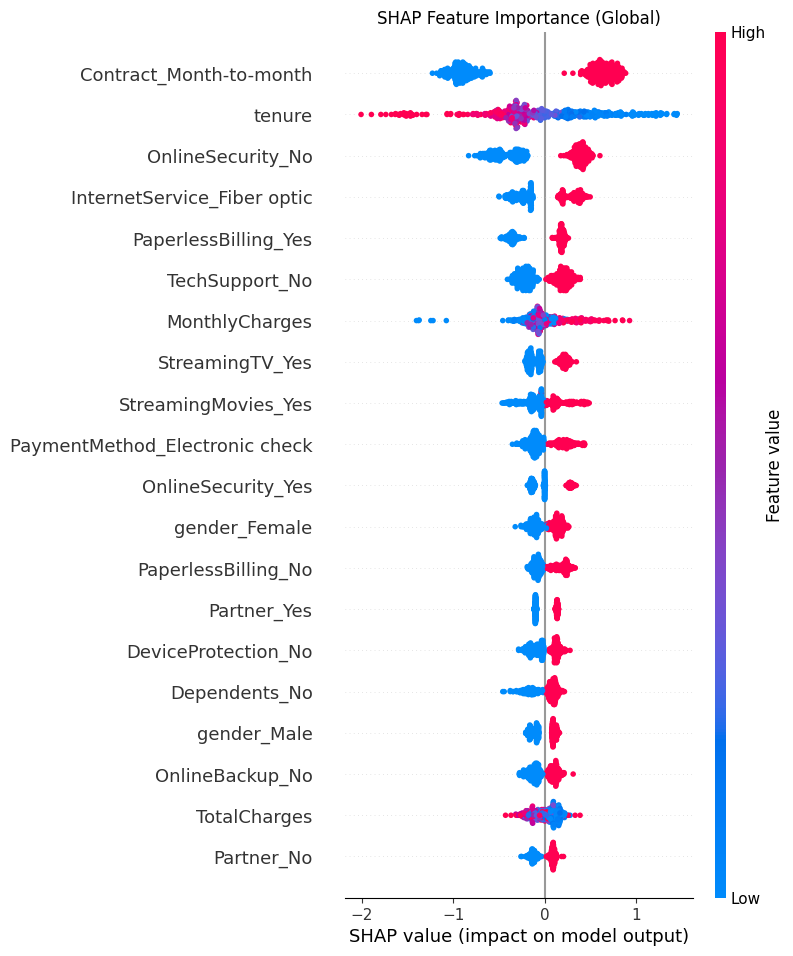

In [ ]:
def generate_shap_insights(pipeline, X_sample):
    """
    Generates SHAP summary plots to explain model predictions.
    Args:
        pipeline: Trained pipeline.
        X_sample: A sample of X data (pre-splitting or test set) to explain.
    """
    print("🧠 Calculating SHAP Values for Interpretability...")

    # Extract model and preprocessor
    model = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessor']

    # Transform data to match what the model sees
    X_transformed = preprocessor.transform(X_sample)

    # Get feature names from the OneHotEncoder
    # Note: This is a bit tricky, relying on the 'cat' step naming convention
    try:
        cat_encoder = preprocessor.named_transformers_['cat']['onehot']
        cat_names = cat_encoder.get_feature_names_out(config.CAT_FEATURES)
        feature_names = list(config.NUM_FEATURES) + list(cat_names)
    except:
        feature_names = None # Fallback if extraction fails

    # Create SHAP explainer
    explainer = shap.Explainer(model, X_transformed)
    shap_values = explainer(X_transformed)

    if feature_names is not None:
        shap_values.feature_names = feature_names

    # Plot
    plt.figure()
    shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)
    plt.title("SHAP Feature Importance (Global)")
    plt.show()

# --- EXECUTION BLOCK ---
# Using a small sample of test data for speed
X_shap_sample = X_test.iloc[:500]
generate_shap_insights(pipeline, X_shap_sample)

# **Module: Retention Strategy & Risk Scoring**

In [ ]:
class RetentionStrategist:
    """
    Converts model probabilities into business actions.
    """
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def segment_customers(self, df_input: pd.DataFrame):
        """
        Scores new data and assigns Risk Tiers and Retention Actions.
        """
        # Get Probability of Churn (Class 1)
        probs = self.pipeline.predict_proba(df_input)[:, 1]

        results = df_input.copy()
        results['Churn_Probability'] = probs

        # Define Tiers
        conditions = [
            (results['Churn_Probability'] > 0.75),
            (results['Churn_Probability'] > 0.50),
            (results['Churn_Probability'] > 0.25)
        ]
        tiers = ['Critical', 'High', 'Medium']
        actions = [
            'Immediate Personal Outreach + Custom Discount',
            'Targeted Email Campaign + Service Upgrade Offer',
            'Automated Check-in + Loyalty Points Reminder'
        ]

        results['Risk_Tier'] = np.select(conditions, tiers, default='Low')
        results['Recommended_Action'] = np.select(conditions, actions, default='Monitor')

        return results

# --- EXECUTION BLOCK ---
strategist = RetentionStrategist(pipeline)
risk_assessment = strategist.segment_customers(X_test)

# Displaying High Risk Customers for the Business Dashboard
print("🚩 High Risk Customer Segment (Example):")
display(risk_assessment[risk_assessment['Risk_Tier'] == 'Critical'].head(5)[
    ['Churn_Probability', 'Risk_Tier', 'Recommended_Action', 'Contract', 'MonthlyCharges']
])

🚩 High Risk Customer Segment (Example):


,Churn_Probability,Risk_Tier,Recommended_Action,Contract,MonthlyCharges
2280,0.879167,Critical,Immediate Personal Outreach + Custom Discount,Month-to-month,100.15
5748,0.761001,Critical,Immediate Personal Outreach + Custom Discount,Month-to-month,99.85
3524,0.821833,Critical,Immediate Personal Outreach + Custom Discount,Month-to-month,84.80
6529,0.817259,Critical,Immediate Personal Outreach + Custom Discount,Month-to-month,74.85
6125,0.833890,Critical,Immediate Personal Outreach + Custom Discount,Month-to-month,102.25


# **Serialization (Saving the Brain)**

In [ ]:
# Save the entire pipeline (Preprocessor + SMOTE + Model)
model_filename = 'bizlens_churn_pipeline.joblib'
joblib.dump(pipeline, model_filename)

print(f"💾 Pipeline saved to {model_filename}")
print("ready for deployment in Streamlit backend.")

💾 Pipeline saved to bizlens_churn_pipeline.joblib
ready for deployment in Streamlit backend.
